# Threshold Exceedance Analysis: Oregon vs. Aruba

This notebook evaluates physical and biogeochemical datasets against critical environmental threshold limits for marine species:
1. **pH stress events**: pH $\le 7.2$ or $\ge 8.4$
2. **Salinity Stress (Species Guilds)**:
   - **Pelagic & Open Ocean Species** (Tuna, Mackerel, Pelagic Sharks): Salinity $< 30$ or $> 38$ psu
   - **Coral Reef Species** (Damselfish, Tangs, Angelfish, Wrasses): Salinity $< 25$ or $> 42$ psu
   - **Coastal, Estuarine & Benthic Species** (Flounder, Halibut, Groupers, Mullet, Killifish): Salinity $< 18$ or $> 70$ psu
3. **Thermal stress events (Coral & Reef Stress)**:
   - Days > 29.5 °C
   - Days > 30.0 °C
   - Days > 30.5 °C
   - Days > 31.0 °C

We compare these exceedance events between the Oregon and Aruba datasets over a 48-month period (July 4, 2022 to June 4, 2026), analyzed by dataset, chronological year, and month.

In [13]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### 1. Load and Merge Datasets
We load the physical and biogeochemical NetCDF datasets, convert them to DataFrames, round coordinates to 3 decimals to align grids, and perform inner merges to build separate location DataFrames.

In [14]:
dest_dir = '.'

# Load NetCDF files
ds_oregon_phy = xr.open_dataset(os.path.join(dest_dir, 'oregon_phy2.nc'))
ds_oregon_bgc = xr.open_dataset(os.path.join(dest_dir, 'oregon_bgc2.nc'))
ds_aruba_phy = xr.open_dataset(os.path.join(dest_dir, 'aruba_phy.nc'))
ds_aruba_bgc = xr.open_dataset(os.path.join(dest_dir, 'aruba_bgc.nc'))

# Convert to DataFrames
df_oregon_phy = ds_oregon_phy.to_dataframe().reset_index()
df_oregon_bgc = ds_oregon_bgc.to_dataframe().reset_index()
df_aruba_phy = ds_aruba_phy.to_dataframe().reset_index()
df_aruba_bgc = ds_aruba_bgc.to_dataframe().reset_index()

# Merge Oregon (Physics and BGC)
df_oregon_phy['date'] = df_oregon_phy['time'].dt.date
df_oregon_bgc['date'] = df_oregon_bgc['time'].dt.date
df_oregon_phy['lat_round'] = df_oregon_phy['latitude'].round(3)
df_oregon_phy['lon_round'] = df_oregon_phy['longitude'].round(3)
df_oregon_bgc['lat_round'] = df_oregon_bgc['latitude'].round(3)
df_oregon_bgc['lon_round'] = df_oregon_bgc['longitude'].round(3)

df_oregon = pd.merge(
    df_oregon_phy,
    df_oregon_bgc[['date', 'lat_round', 'lon_round', 'ph', 'dissic', 'talk']],
    on=['date', 'lat_round', 'lon_round'],
    how='inner'
)

# Merge Aruba (Physics and BGC)
df_aruba_phy['date'] = df_aruba_phy['time'].dt.date
df_aruba_bgc['date'] = df_aruba_bgc['time'].dt.date
df_aruba_phy['lat_round'] = df_aruba_phy['latitude'].round(3)
df_aruba_phy['lon_round'] = df_aruba_phy['longitude'].round(3)
df_aruba_bgc['lat_round'] = df_aruba_bgc['latitude'].round(3)
df_aruba_bgc['lon_round'] = df_aruba_bgc['longitude'].round(3)

df_aruba = pd.merge(
    df_aruba_phy,
    df_aruba_bgc[['date', 'lat_round', 'lon_round', 'ph', 'dissic', 'talk']],
    on=['date', 'lat_round', 'lon_round'],
    how='inner'
)

# Parse times, extract dates, and setup chronological years
for df_loc in [df_oregon, df_aruba]:
    df_loc['time'] = pd.to_datetime(df_loc['time'])
    df_loc['year'] = df_loc['time'].dt.year
    df_loc['month'] = df_loc['time'].dt.month
    df_loc['year_month'] = df_loc['time'].dt.strftime('%Y-%m')
    
    start_date = df_loc['time'].min()
    y1_end = start_date + pd.DateOffset(years=1)
    y2_end = start_date + pd.DateOffset(years=2)
    y3_end = start_date + pd.DateOffset(years=3)
    
    df_loc['chrono_year'] = 'Year 4'
    df_loc.loc[(df_loc['time'] >= start_date) & (df_loc['time'] < y1_end), 'chrono_year'] = 'Year 1'
    df_loc.loc[(df_loc['time'] >= y1_end) & (df_loc['time'] < y2_end), 'chrono_year'] = 'Year 2'
    df_loc.loc[(df_loc['time'] >= y2_end) & (df_loc['time'] < y3_end), 'chrono_year'] = 'Year 3'

print(f'Oregon merged dataframe rows: {len(df_oregon)}')
print(f'Aruba merged dataframe rows: {len(df_aruba)}')

Oregon merged dataframe rows: 102999
Aruba merged dataframe rows: 68666


### 2. Evaluate Threshold Exceedances (Overall)
We define the logical threshold boundaries and compute overall exceedance metrics:
- **Hours**: Total count of hourly records violating the threshold.
- **Grid-Days**: Number of unique `(date, lat_round, lon_round)` combinations that exceed the threshold (which corrects for spatial grid density and time resolution).

In [15]:
# Exceedance conditions including the 3 biological salinity stress guilds
thresholds = {
    'pH (<= 7.2 or >= 8.4)': lambda d: (d['ph'] <= 7.2) | (d['ph'] >= 8.4),
    'Pelagic Stress (<30 or >38 psu)': lambda d: (d['so'] < 30) | (d['so'] > 38),
    'Coral Reef Stress (<25 or >42 psu)': lambda d: (d['so'] < 25) | (d['so'] > 42),
    'Coastal & Benthic Stress (<18 or >70 psu)': lambda d: (d['so'] < 18) | (d['so'] > 70),
    'Temp > 29.5 °C': lambda d: d['thetao'] > 29.5,
    'Temp > 30.0 °C': lambda d: d['thetao'] > 30.0,
    'Temp > 30.5 °C': lambda d: d['thetao'] > 30.5,
    'Temp > 31.0 °C': lambda d: d['thetao'] > 31.0
}

def get_overall_exceedances(df_loc, label):
    records = []
    for name, cond in thresholds.items():
        mask = cond(df_loc)
        df_ex = df_loc[mask]
        hours_count = len(df_ex)
        # Unique date-coordinate combinations
        days_count = df_ex.groupby(['date', 'lat_round', 'lon_round']).size().shape[0]
        records.append({
            'Location': label,
            'Threshold': name,
            'Hours': hours_count,
            'Days': days_count
        })
    return pd.DataFrame(records)

df_oregon_ex = get_overall_exceedances(df_oregon, 'Oregon')
df_aruba_ex = get_overall_exceedances(df_aruba, 'Aruba')
df_total_ex = pd.concat([df_oregon_ex, df_aruba_ex], ignore_index=True)

print('--- Total Threshold Exceedances Summary ---')
display(df_total_ex)

--- Total Threshold Exceedances Summary ---


,Location,Threshold,Hours,Days
0,Oregon,pH (<= 7.2 or >= 8.4),0,0
1,Oregon,Pelagic Stress (<30 or >38 psu),33616,1547
2,Oregon,Coral Reef Stress (<25 or >42 psu),0,0
3,Oregon,Coastal & Benthic Stress (<18 or >70 psu),0,0
4,Oregon,Temp > 29.5 °C,0,0
5,Oregon,Temp > 30.0 °C,0,0
6,Oregon,Temp > 30.5 °C,0,0
7,Oregon,Temp > 31.0 °C,0,0
8,Aruba,pH (<= 7.2 or >= 8.4),0,0
9,Aruba,Pelagic Stress (<30 or >38 psu),0,0


### 3. Visualizing Overall Exceedances per Dataset
We compare the overall exceedance frequencies between the cold-water upwelling Oregon coast and the tropical reef-lined Aruba coast.

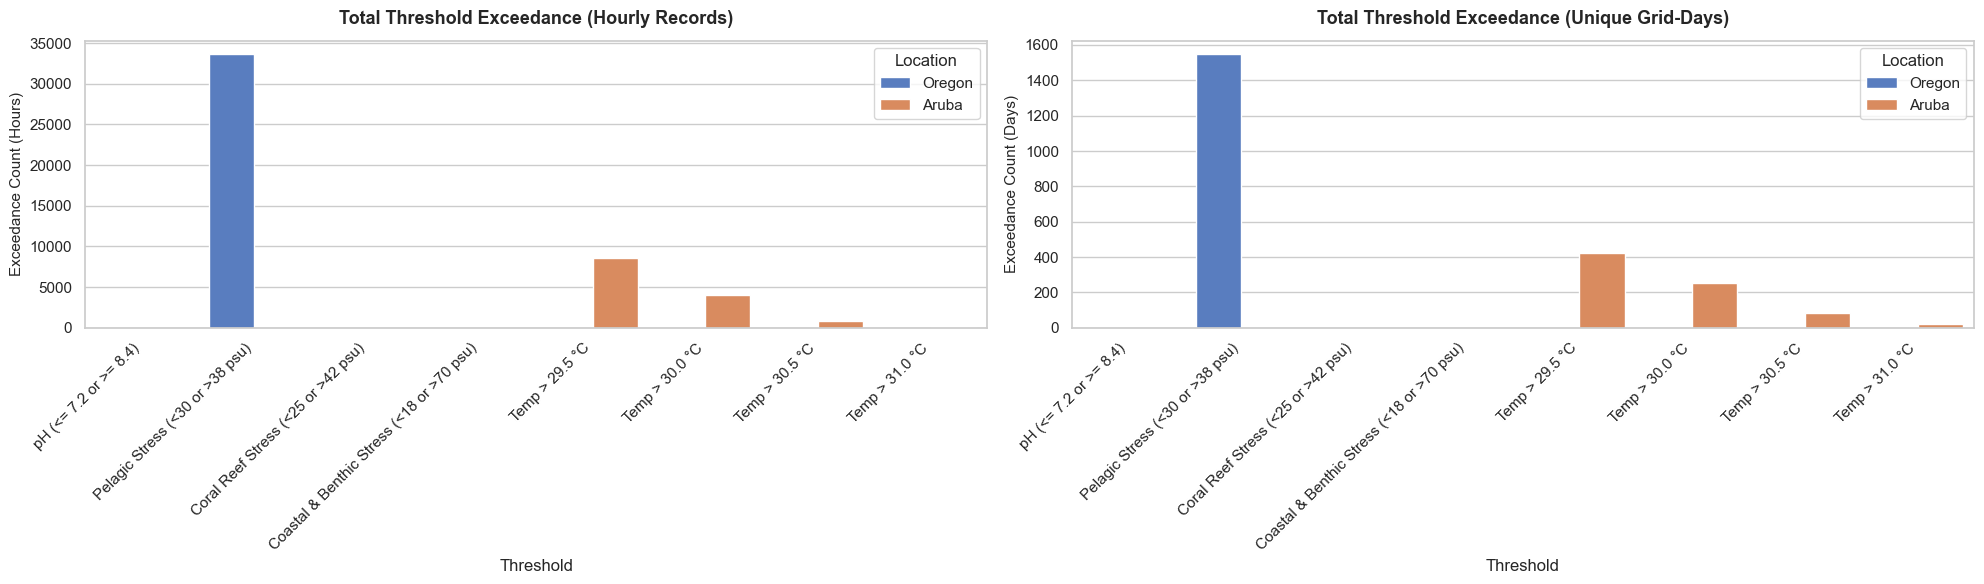

In [16]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Plot Hours Exceedance
sns.barplot(data=df_total_ex, x='Threshold', y='Hours', hue='Location', ax=axes[0], palette='muted')
axes[0].set_title('Total Threshold Exceedance (Hourly Records)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Exceedance Count (Hours)', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# 2. Plot Grid-Days Exceedance
sns.barplot(data=df_total_ex, x='Threshold', y='Days', hue='Location', ax=axes[1], palette='muted')
axes[1].set_title('Total Threshold Exceedance (Unique Grid-Days)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 4. Yearly Threshold Exceedance Analysis
We break down the counts of threshold violations by chronological year (Year 1 to Year 4) to check if stress events are increasing or decreasing over the study timeline.

In [17]:
def get_yearly_exceedances(df_loc, label):
    records = []
    years = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
    for yr in years:
        df_yr = df_loc[df_loc['chrono_year'] == yr]
        for name, cond in thresholds.items():
            mask = cond(df_yr)
            df_ex = df_yr[mask]
            hours_count = len(df_ex)
            days_count = df_ex.groupby(['date', 'lat_round', 'lon_round']).size().shape[0]
            records.append({
                'Location': label,
                'Year': yr,
                'Threshold': name,
                'Hours': hours_count,
                'Days': days_count
            })
    return pd.DataFrame(records)

df_oregon_yr = get_yearly_exceedances(df_oregon, 'Oregon')
df_aruba_yr = get_yearly_exceedances(df_aruba, 'Aruba')
df_yr_ex = pd.concat([df_oregon_yr, df_aruba_yr], ignore_index=True)

print('--- Oregon Yearly Exceedances ---')
display(df_yr_ex[df_yr_ex['Location'] == 'Oregon'].pivot(index='Threshold', columns='Year', values='Days'))

print('\n--- Aruba Yearly Exceedances ---')
display(df_yr_ex[df_yr_ex['Location'] == 'Aruba'].pivot(index='Threshold', columns='Year', values='Days'))

--- Oregon Yearly Exceedances ---


Year,Year 1,Year 2,Year 3,Year 4
Threshold,,,,
Coastal & Benthic Stress (<18 or >70 psu),0,0,0,0
Coral Reef Stress (<25 or >42 psu),0,0,0,0
Pelagic Stress (<30 or >38 psu),397,329,417,404
Temp > 29.5 °C,0,0,0,0
Temp > 30.0 °C,0,0,0,0
Temp > 30.5 °C,0,0,0,0
Temp > 31.0 °C,0,0,0,0
pH (<= 7.2 or >= 8.4),0,0,0,0



--- Aruba Yearly Exceedances ---


Year,Year 1,Year 2,Year 3,Year 4
Threshold,,,,
Coastal & Benthic Stress (<18 or >70 psu),0,0,0,0
Coral Reef Stress (<25 or >42 psu),0,0,0,0
Pelagic Stress (<30 or >38 psu),0,0,0,0
Temp > 29.5 °C,72,136,166,48
Temp > 30.0 °C,21,104,106,21
Temp > 30.5 °C,5,41,32,4
Temp > 31.0 °C,0,9,10,0
pH (<= 7.2 or >= 8.4),0,0,0,0


#### Visualizing Yearly Trends
We plot the yearly breakdowns. Since Oregon has non-zero counts for Pelagic salinity stress, we show plots for both regions where violations occur.

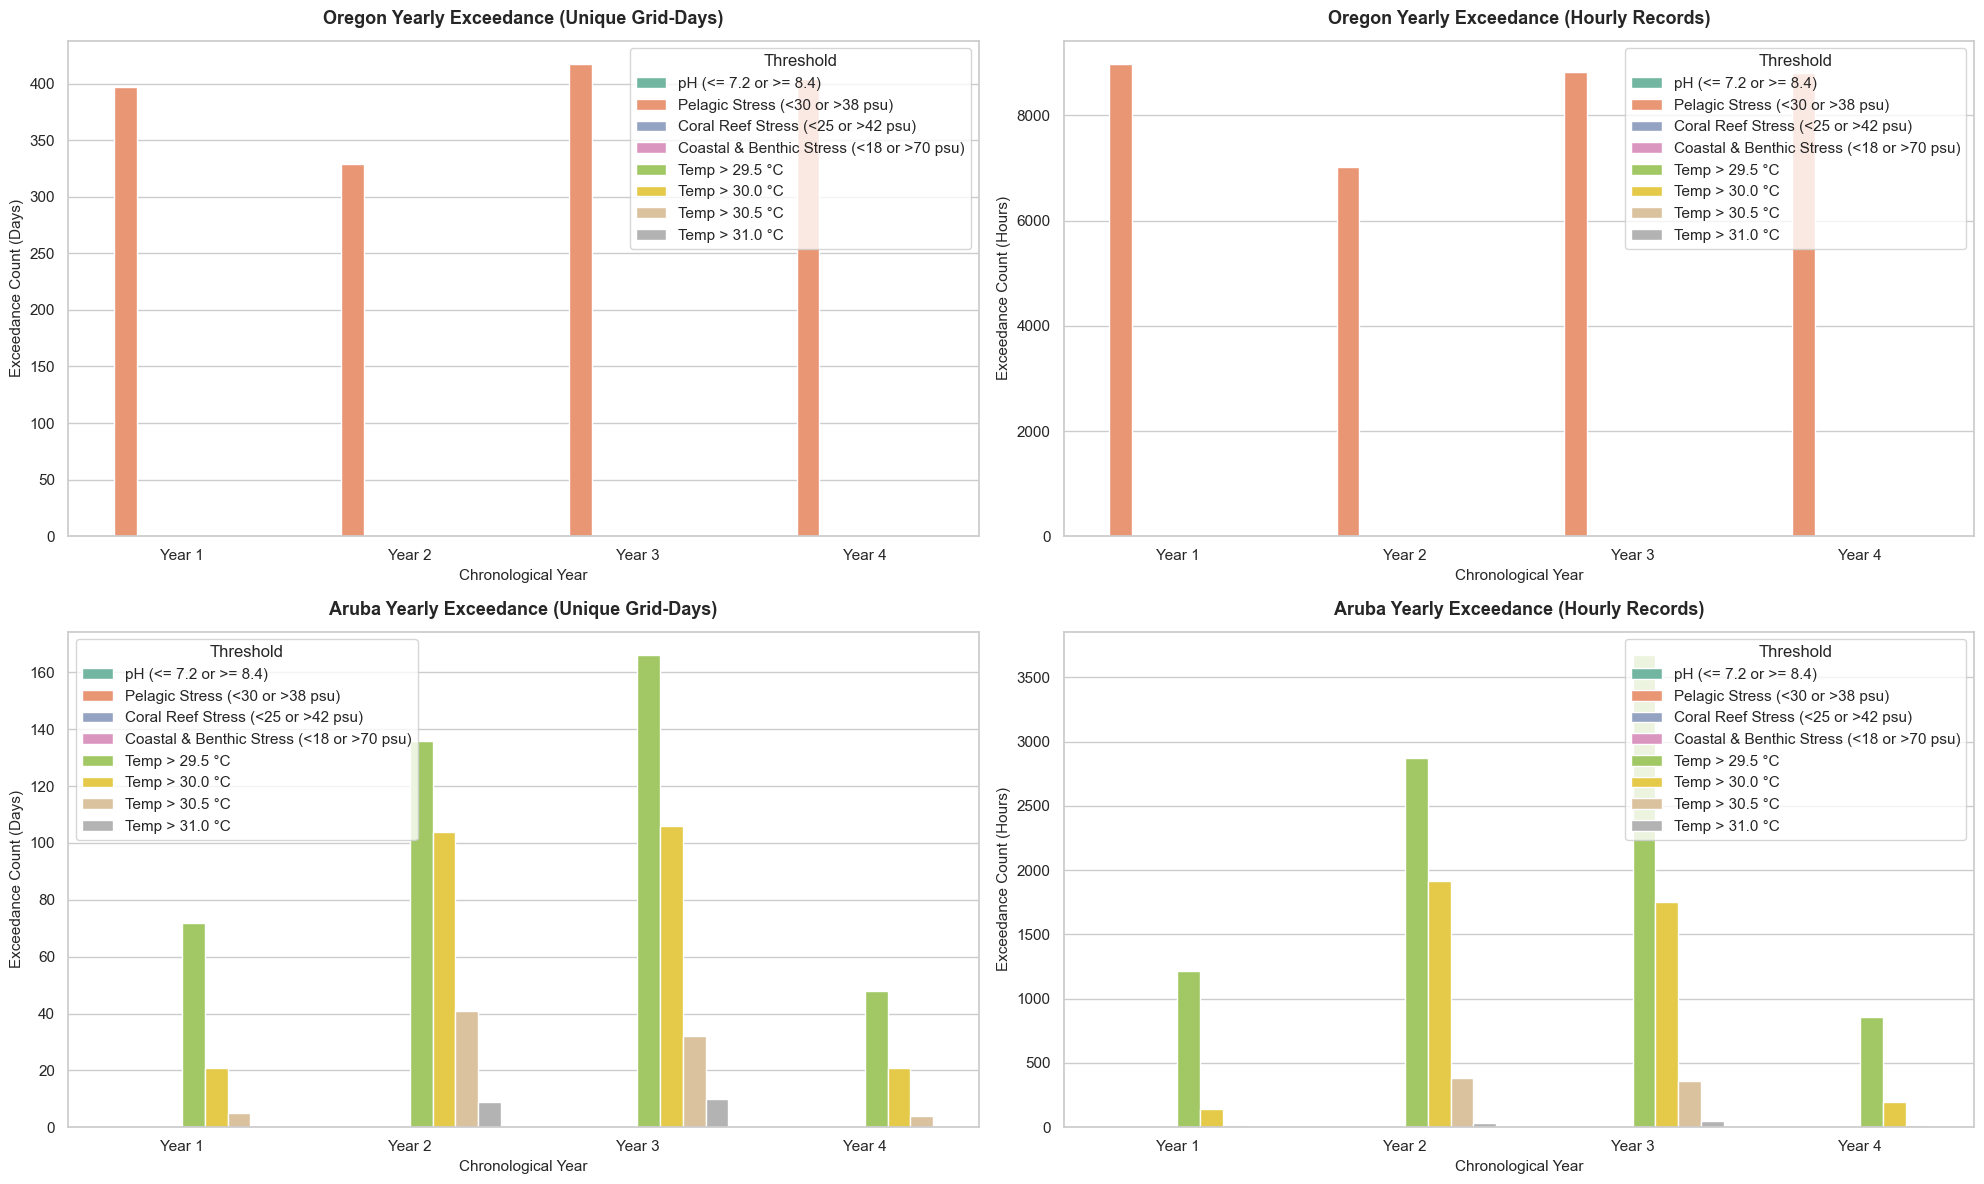

In [18]:
# Filter data where exceedances occur to avoid empty plots
df_aruba_yr_data = df_yr_ex[df_yr_ex['Location'] == 'Aruba']
df_oregon_yr_data = df_yr_ex[df_yr_ex['Location'] == 'Oregon']

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Oregon Yearly Grid-Days
sns.barplot(data=df_oregon_yr_data, x='Year', y='Days', hue='Threshold', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Oregon Yearly Exceedance (Unique Grid-Days)', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[0, 0].set_xlabel('Chronological Year', fontsize=11)

# 2. Oregon Yearly Hours
sns.barplot(data=df_oregon_yr_data, x='Year', y='Hours', hue='Threshold', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Oregon Yearly Exceedance (Hourly Records)', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].set_ylabel('Exceedance Count (Hours)', fontsize=11)
axes[0, 1].set_xlabel('Chronological Year', fontsize=11)

# 3. Aruba Yearly Grid-Days
sns.barplot(data=df_aruba_yr_data, x='Year', y='Days', hue='Threshold', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Aruba Yearly Exceedance (Unique Grid-Days)', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[1, 0].set_xlabel('Chronological Year', fontsize=11)

# 4. Aruba Yearly Hours
sns.barplot(data=df_aruba_yr_data, x='Year', y='Hours', hue='Threshold', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Aruba Yearly Exceedance (Hourly Records)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].set_ylabel('Exceedance Count (Hours)', fontsize=11)
axes[1, 1].set_xlabel('Chronological Year', fontsize=11)

plt.tight_layout()
plt.show()

#### Spatial Mapping of Yearly Exceedances (Cartopy)

To analyze the spatial distribution and temporal progression of environmental threshold violations, we use Cartopy to generate spatial maps for each chronological year (Year 1 to Year 4):
- **Oregon Region**: Salinity exceedances under Pelagic Stress conditions (`so < 30` or `so > 38` psu).
- **Aruba Region**: Temperature exceedances violating reef health conditions (`thetao > 30.0` °C).

The maps are smoothed using bilinear interpolation (rescaled to a 100x100 grid) and draw gridlines with coordinates for precise geographic mapping.

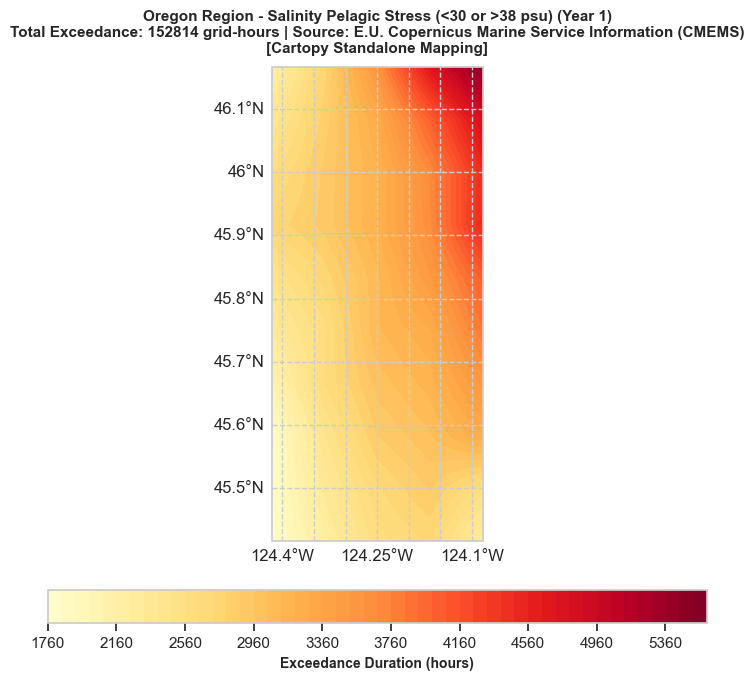

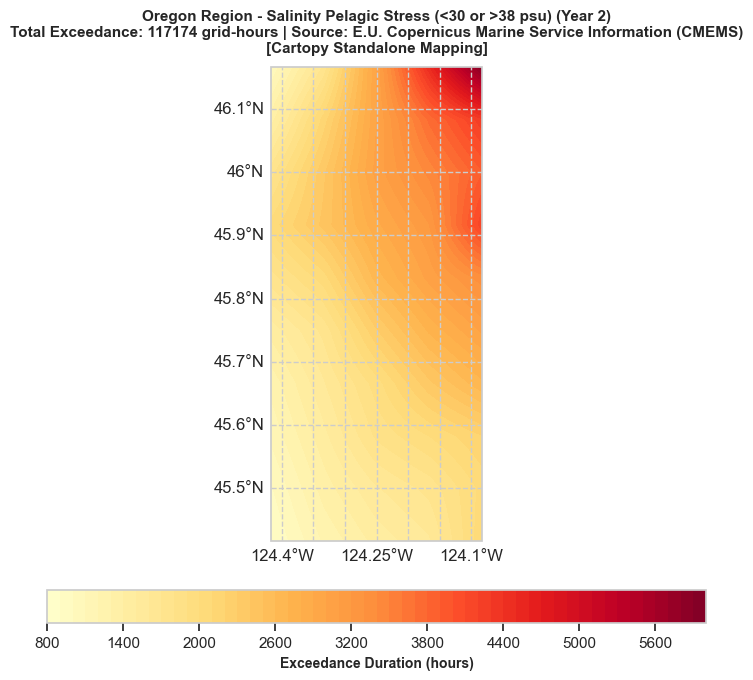

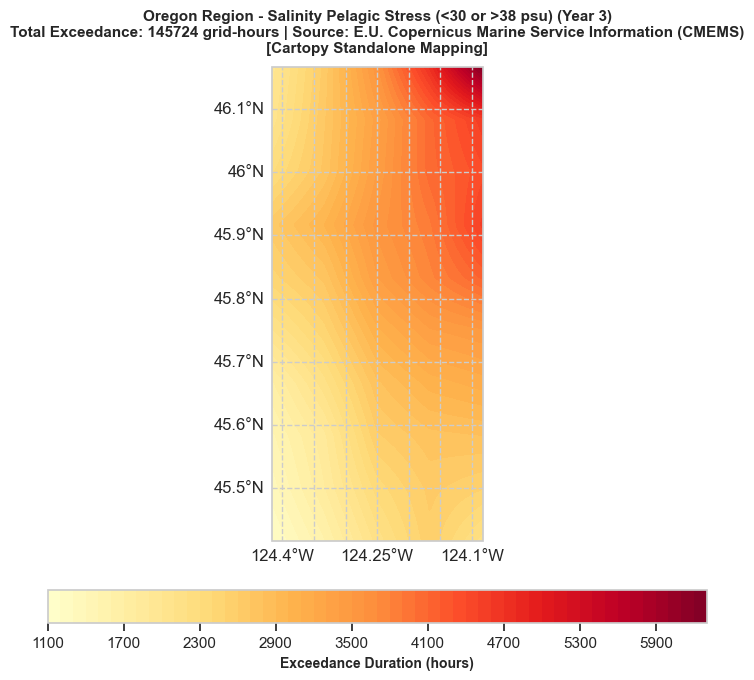

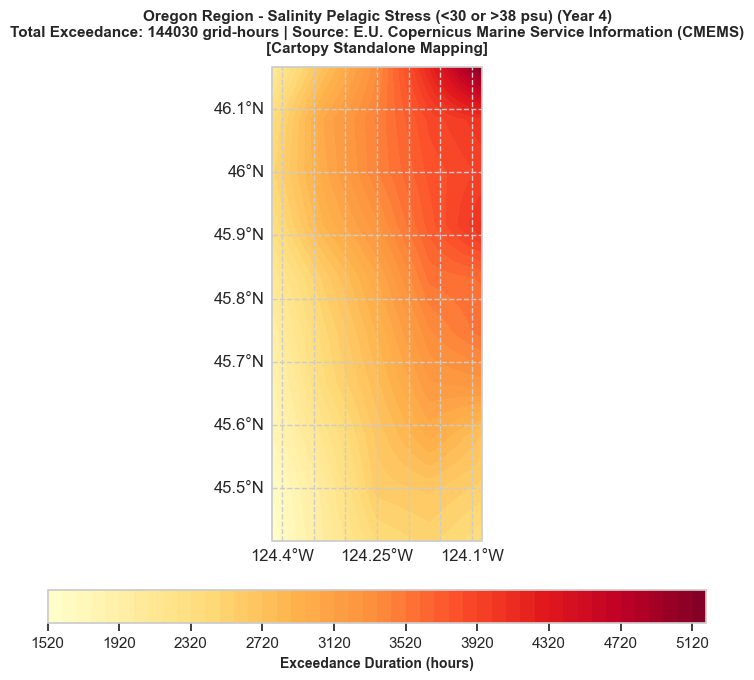

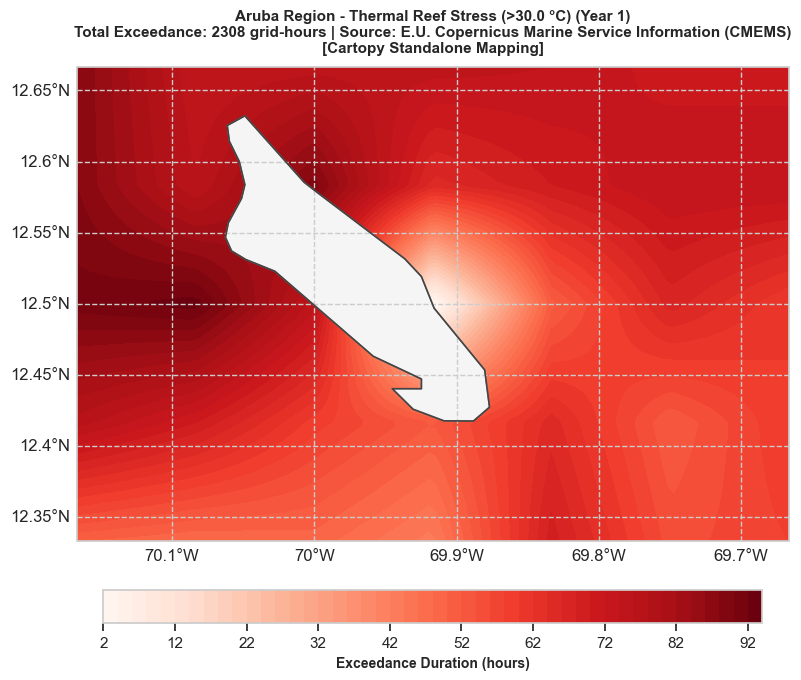

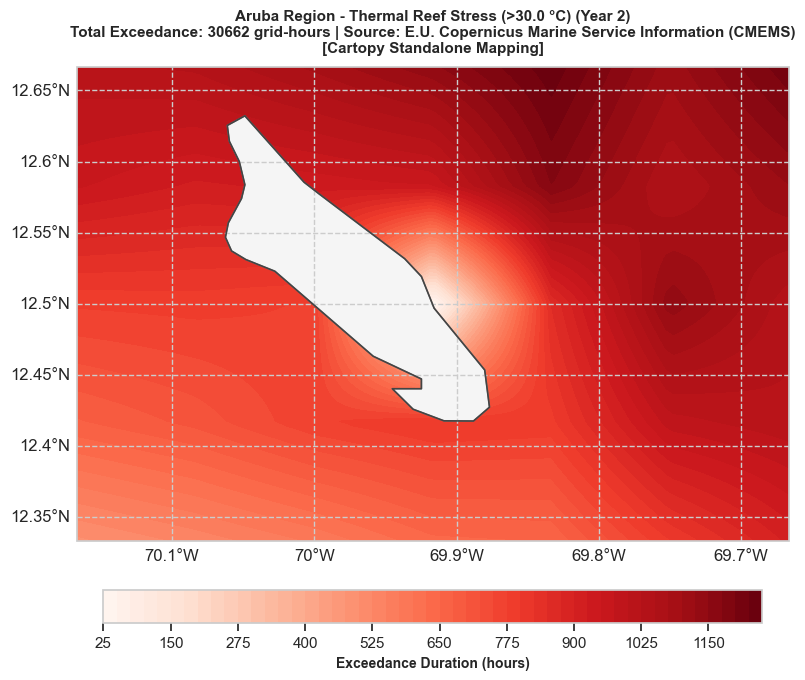

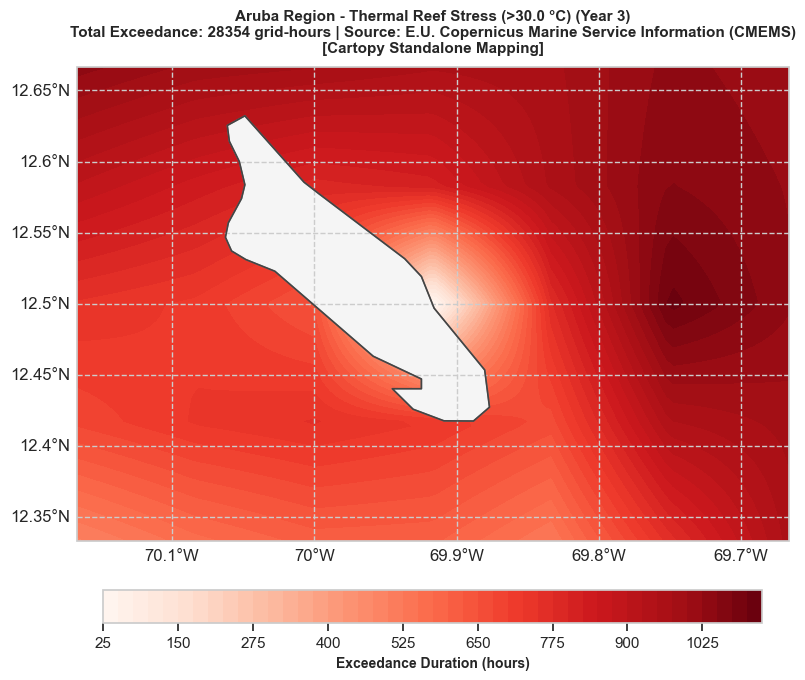

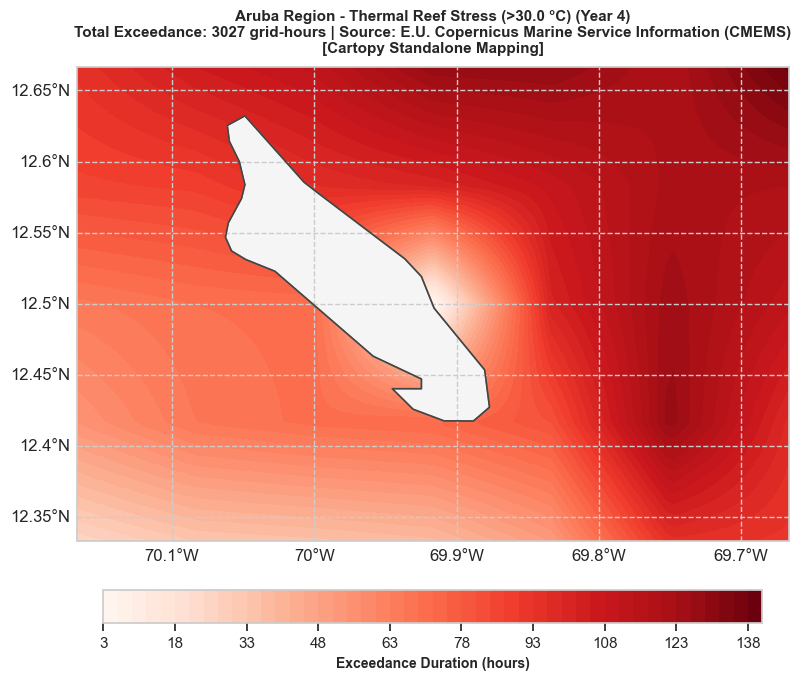

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings('ignore')

# 1. Load NetCDF datasets for spatial analysis
ds_oregon_phy_map = xr.open_dataset('oregon_phy2.nc').isel(depth=0)
ds_aruba_phy_map = xr.open_dataset('aruba_phy.nc').isel(depth=0)

# 2. Configure regions and thresholds
map_configs = {
    'Oregon': {
        'ds': ds_oregon_phy_map,
        'threshold_name': 'Salinity Pelagic Stress (<30 or >38 psu)',
        'threshold_cond': lambda ds: (ds['so'] < 30.0) | (ds['so'] > 38.0),
        'cmap': 'YlOrRd',
        'source': ds_oregon_phy_map.attrs.get('credit', 'Copernicus Marine Service'),
        'units': 'hours'
    },
    'Aruba': {
        'ds': ds_aruba_phy_map,
        'threshold_name': 'Thermal Reef Stress (>30.0 °C)',
        'threshold_cond': lambda ds: ds['thetao'] > 30.0,
        'cmap': 'Reds',
        'source': ds_aruba_phy_map.attrs.get('credit', 'Copernicus Marine Service'),
        'units': 'hours'
    }
}

# 3. Iterate and plot all 8 maps (4 years x 2 regions)
for label, info in map_configs.items():
    ds = info['ds']
    start_date = ds.time.min().values
    y1_end = start_date + np.timedelta64(365, 'D')
    y2_end = start_date + np.timedelta64(365 * 2, 'D')
    y3_end = start_date + np.timedelta64(365 * 3, 'D')
    
    years_bounds = [
        ('Year 1', start_date, y1_end),
        ('Year 2', y1_end, y2_end),
        ('Year 3', y2_end, y3_end),
        ('Year 4', y3_end, ds.time.max().values)
    ]
    
    # Bounds and smoothing grids
    lat_min, lat_max = float(ds.latitude.min()), float(ds.latitude.max())
    lon_min, lon_max = float(ds.longitude.min()), float(ds.longitude.max())
    fine_lat = np.linspace(lat_min, lat_max, 100)
    fine_lon = np.linspace(lon_min, lon_max, 100)
    
    for yr_name, start, end in years_bounds:
        ds_yr = ds.sel(time=slice(start, end))
        mask = info['threshold_cond'](ds_yr)
        ex_hours = mask.sum(dim='time')
        
        # Spatial interpolation for smooth contours
        ex_smooth = ex_hours.interp(latitude=fine_lat, longitude=fine_lon, method='linear')
        
        # Plot Cartopy Map
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        
        # Geographic features
        ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', edgecolor='#888888', zorder=2)
        ax.add_feature(cfeature.COASTLINE, edgecolor='#444444', linewidth=1.2, zorder=3)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='#888888', zorder=3)
        
        # Plot contour data
        cf = ax.contourf(ex_smooth.longitude, ex_smooth.latitude, ex_smooth, 
                         levels=50, cmap=info['cmap'], transform=ccrs.PlateCarree())
        
        # Add Gridlines & Coordinate Labels
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='#cccccc', zorder=1)
        gl.top_labels = False
        gl.right_labels = False
        
        # Colorbar
        cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.85)
        cbar.set_label(f"Exceedance Duration ({info['units']})", fontsize=10, fontweight='bold')
        
        # Titles & Statistics
        total_ex_sum = int(ex_hours.sum().values)
        plt.title(f"{label} Region - {info['threshold_name']} ({yr_name})\n"
                  f"Total Exceedance: {total_ex_sum} grid-hours | Source: {info['source']}\n"
                  f"[Cartopy Standalone Mapping]", fontsize=11, fontweight='bold', pad=10)
        plt.show()

# Close datasets
ds_oregon_phy_map.close()
ds_aruba_phy_map.close()


### 5. Monthly Seasonal (Climatological) Exceedance Analysis
We group the dataset by calendar month (1 to 12) across all years to evaluate seasonal environmental cycles (such as summer warming or rainy periods).

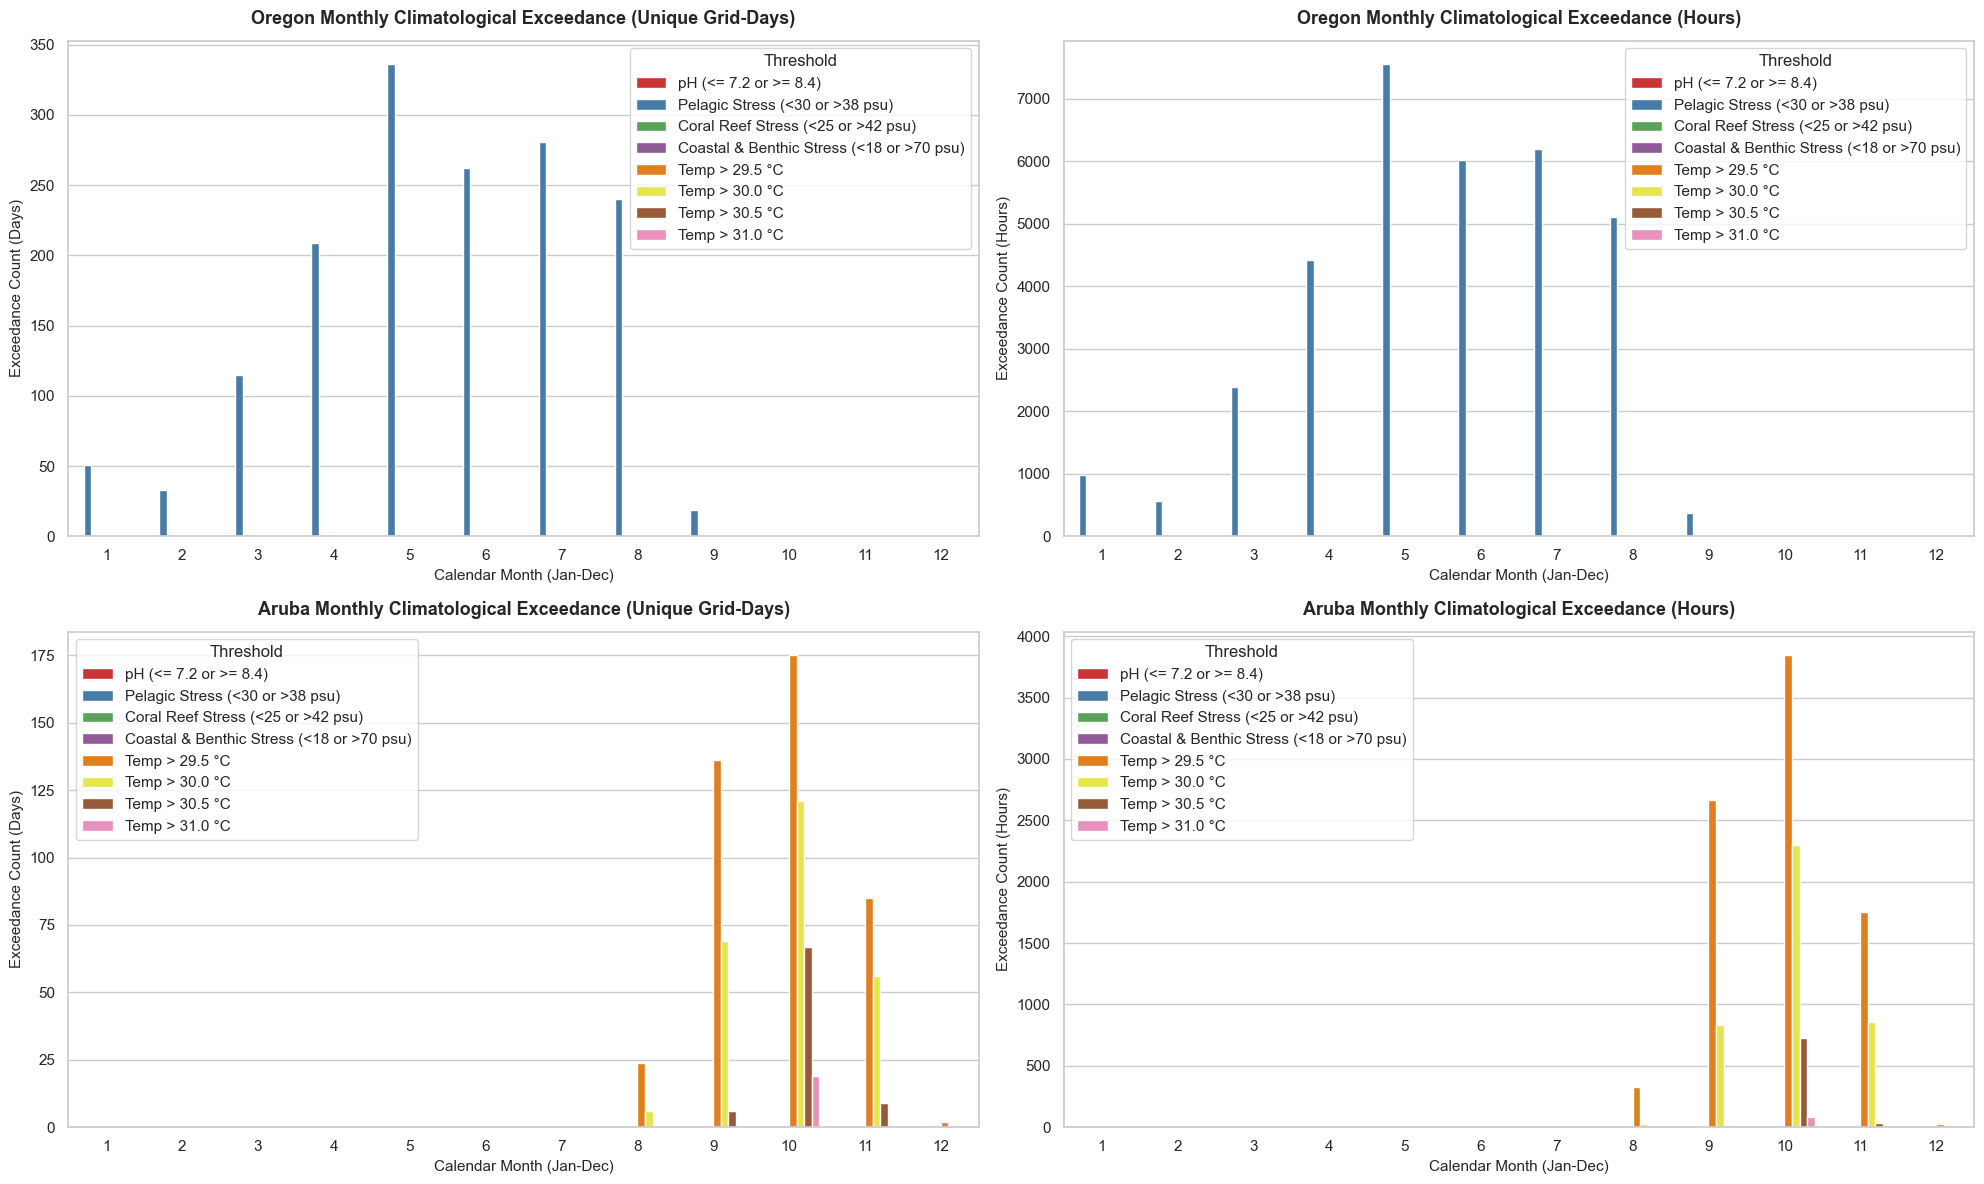

In [20]:
def get_monthly_climatological_exceedances(df_loc, label):
    records = []
    for m in range(1, 13):
        df_m = df_loc[df_loc['month'] == m]
        for name, cond in thresholds.items():
            mask = cond(df_m)
            df_ex = df_m[mask]
            hours_count = len(df_ex)
            days_count = df_ex.groupby(['date', 'lat_round', 'lon_round']).size().shape[0]
            records.append({
                'Location': label,
                'Month': m,
                'Threshold': name,
                'Hours': hours_count,
                'Days': days_count
            })
    return pd.DataFrame(records)

df_oregon_m = get_monthly_climatological_exceedances(df_oregon, 'Oregon')
df_aruba_m = get_monthly_climatological_exceedances(df_aruba, 'Aruba')
df_m_ex = pd.concat([df_oregon_m, df_aruba_m], ignore_index=True)

# Plotting monthly seasonal climatology for Oregon and Aruba
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Oregon Monthly Days
sns.barplot(data=df_m_ex[df_m_ex['Location'] == 'Oregon'], x='Month', y='Days', hue='Threshold', ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Oregon Monthly Climatological Exceedance (Unique Grid-Days)', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[0, 0].set_xlabel('Calendar Month (Jan-Dec)', fontsize=11)

# 2. Oregon Monthly Hours
sns.barplot(data=df_m_ex[df_m_ex['Location'] == 'Oregon'], x='Month', y='Hours', hue='Threshold', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Oregon Monthly Climatological Exceedance (Hours)', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].set_ylabel('Exceedance Count (Hours)', fontsize=11)
axes[0, 1].set_xlabel('Calendar Month (Jan-Dec)', fontsize=11)

# 3. Aruba Monthly Days
sns.barplot(data=df_m_ex[df_m_ex['Location'] == 'Aruba'], x='Month', y='Days', hue='Threshold', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Aruba Monthly Climatological Exceedance (Unique Grid-Days)', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[1, 0].set_xlabel('Calendar Month (Jan-Dec)', fontsize=11)

# 4. Aruba Monthly Hours
sns.barplot(data=df_m_ex[df_m_ex['Location'] == 'Aruba'], x='Month', y='Hours', hue='Threshold', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Aruba Monthly Climatological Exceedance (Hours)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].set_ylabel('Exceedance Count (Hours)', fontsize=11)
axes[1, 1].set_xlabel('Calendar Month (Jan-Dec)', fontsize=11)

plt.tight_layout()
plt.show()

### 6. Chronological Month-by-Month Exceedance Timeline
We evaluate exceedances chronologically across the entire 48-month time series. We track Oregon's Pelagic salinity stress timeline and Aruba's thermal heat stress timeline separately.

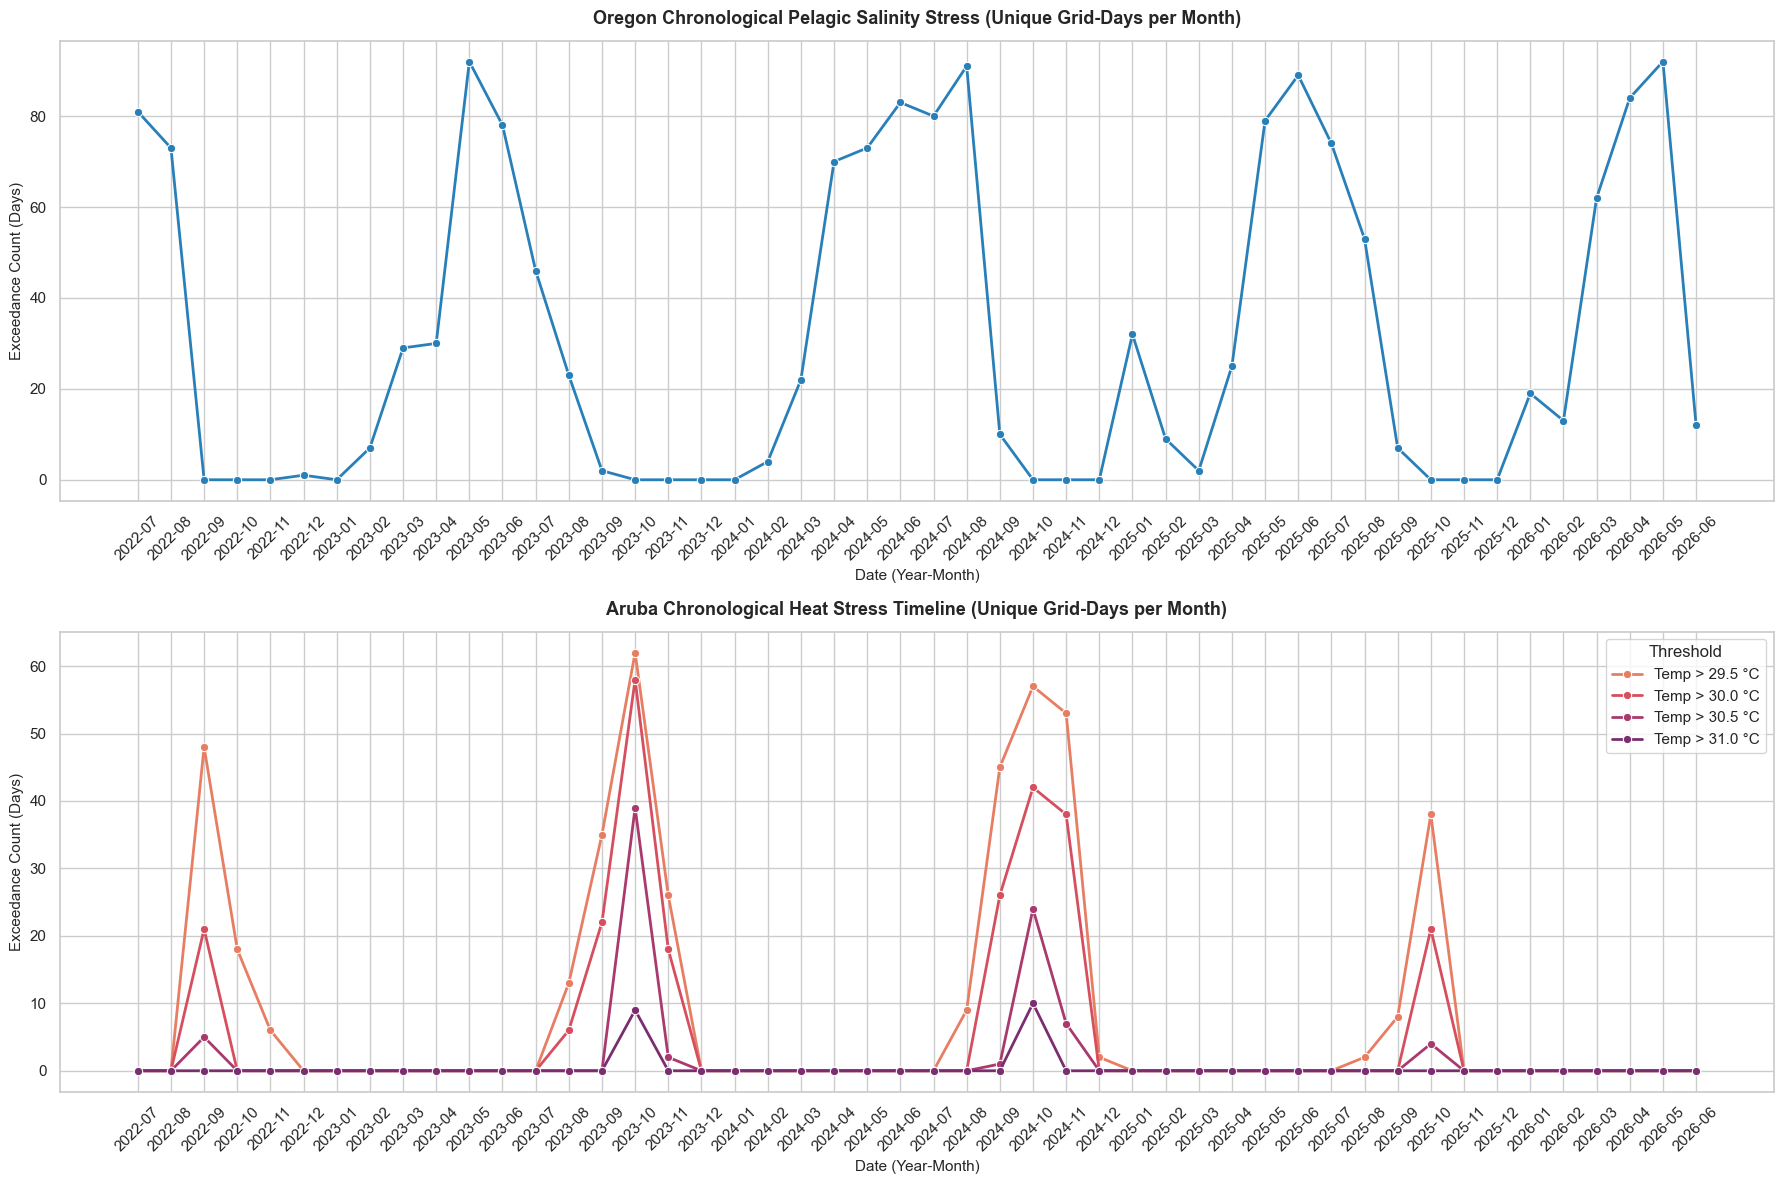

In [21]:
def get_chronological_exceedances(df_loc, label):
    records = []
    months = sorted(df_loc['year_month'].unique())
    for ym in months:
        df_ym = df_loc[df_loc['year_month'] == ym]
        for name, cond in thresholds.items():
            mask = cond(df_ym)
            df_ex = df_ym[mask]
            hours_count = len(df_ex)
            days_count = df_ex.groupby(['date', 'lat_round', 'lon_round']).size().shape[0]
            records.append({
                'Location': label,
                'Year-Month': ym,
                'Threshold': name,
                'Hours': hours_count,
                'Days': days_count
            })
    return pd.DataFrame(records)

df_oregon_chrono = get_chronological_exceedances(df_oregon, 'Oregon')
df_aruba_chrono = get_chronological_exceedances(df_aruba, 'Aruba')

# Set up chronological subplots
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# 1. Oregon Pelagic Salinity Stress Chronological Line Plot
df_oregon_pel = df_oregon_chrono[df_oregon_chrono['Threshold'] == 'Pelagic Stress (<30 or >38 psu)']
sns.lineplot(data=df_oregon_pel, x='Year-Month', y='Days', ax=axes[0], marker='o', linewidth=2, color='#2980b9')
axes[0].set_title('Oregon Chronological Pelagic Salinity Stress (Unique Grid-Days per Month)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[0].set_xlabel('Date (Year-Month)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# 2. Aruba Heat Stress Chronological Line Plot
thermal_thresholds = ['Temp > 29.5 °C', 'Temp > 30.0 °C', 'Temp > 30.5 °C', 'Temp > 31.0 °C']
df_aruba_temp = df_aruba_chrono[df_aruba_chrono['Threshold'].isin(thermal_thresholds)]
sns.lineplot(data=df_aruba_temp, x='Year-Month', y='Days', hue='Threshold', ax=axes[1], marker='o', linewidth=2, palette='flare')
axes[1].set_title('Aruba Chronological Heat Stress Timeline (Unique Grid-Days per Month)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Exceedance Count (Days)', fontsize=11)
axes[1].set_xlabel('Date (Year-Month)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 7. Export Exceedance Statistics to CSV
We save the consolidated exceedance results to a CSV file for reporting or external modeling.

### 8. Salinity Boxplot Analysis (Pelagic Stress Context)

This section visualizes the distribution of salinity values (`so`) for Oregon and Aruba relative to the stable pelagic species requirements (~35 psu, with lower limit 30 psu and upper limit 38 psu).

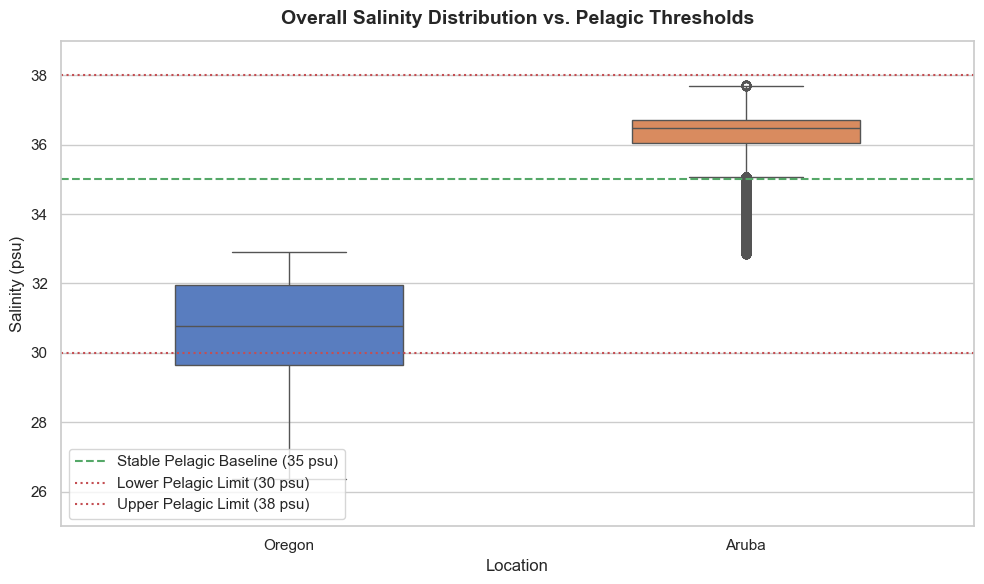

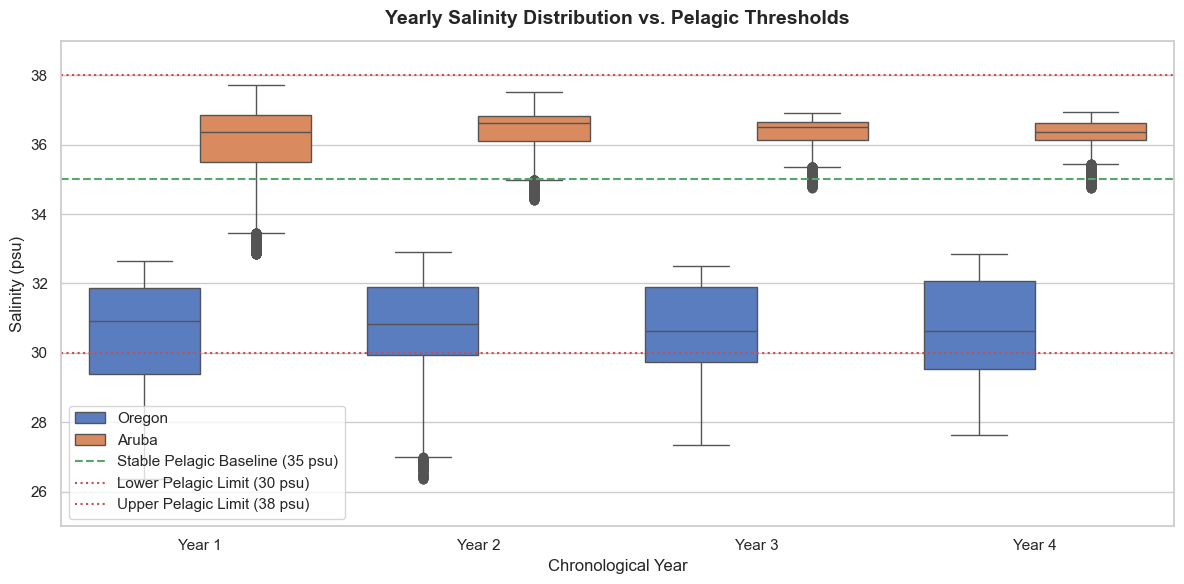

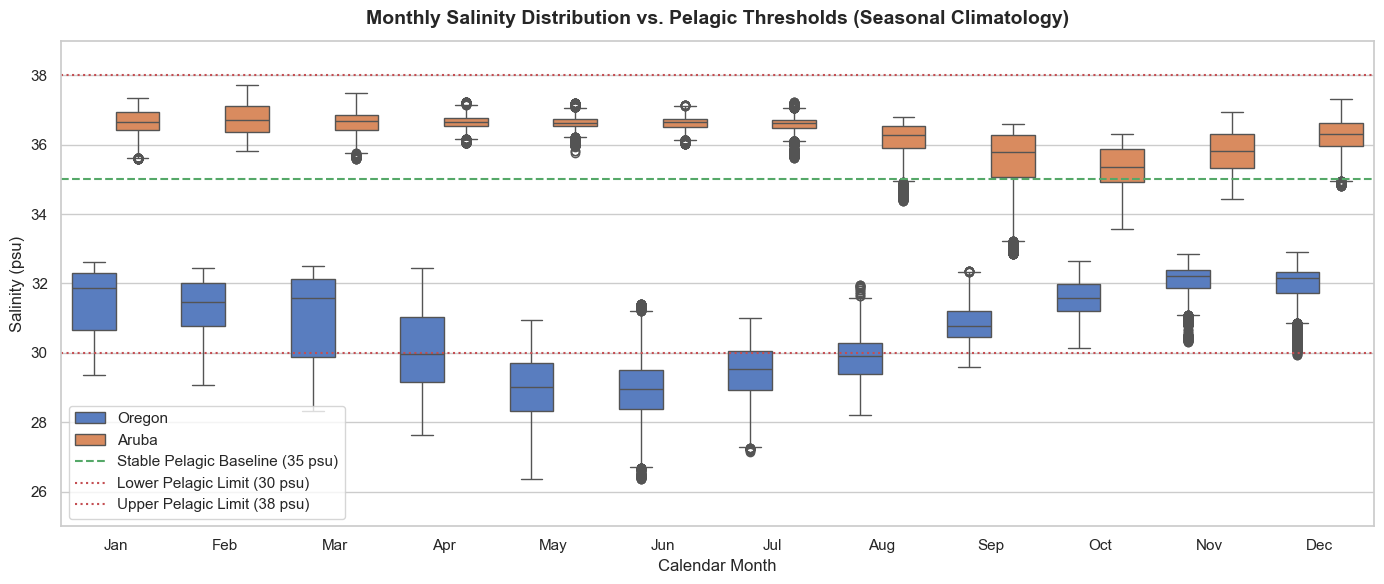

In [22]:
# Combine datasets for plotting salinity boxplots
df_oregon_copy = df_oregon.copy()
df_aruba_copy = df_aruba.copy()
df_oregon_copy['Location'] = 'Oregon'
df_aruba_copy['Location'] = 'Aruba'
df_combined_sal = pd.concat([df_oregon_copy, df_aruba_copy], ignore_index=True)

# Set visual style
sns.set_theme(style='whitegrid')

# 1. Overall Salinity Boxplot vs. Pelagic Thresholds
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined_sal, x='Location', y='so', palette='muted', width=0.5)
plt.axhline(y=35.0, color='g', linestyle='--', linewidth=1.5, label='Stable Pelagic Baseline (35 psu)')
plt.axhline(y=30.0, color='r', linestyle=':', linewidth=1.5, label='Lower Pelagic Limit (30 psu)')
plt.axhline(y=38.0, color='r', linestyle=':', linewidth=1.5, label='Upper Pelagic Limit (38 psu)')
plt.title('Overall Salinity Distribution vs. Pelagic Thresholds', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Salinity (psu)', fontsize=12)
plt.xlabel('Location', fontsize=12)
plt.ylim(25, 39)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

# 2. Yearly Salinity Boxplot vs. Pelagic Thresholds
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined_sal, x='chrono_year', y='so', hue='Location', palette='muted', order=['Year 1', 'Year 2', 'Year 3', 'Year 4'])
plt.axhline(y=35.0, color='g', linestyle='--', linewidth=1.5, label='Stable Pelagic Baseline (35 psu)')
plt.axhline(y=30.0, color='r', linestyle=':', linewidth=1.5, label='Lower Pelagic Limit (30 psu)')
plt.axhline(y=38.0, color='r', linestyle=':', linewidth=1.5, label='Upper Pelagic Limit (38 psu)')
plt.title('Yearly Salinity Distribution vs. Pelagic Thresholds', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Salinity (psu)', fontsize=12)
plt.xlabel('Chronological Year', fontsize=12)
plt.ylim(25, 39)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

# 3. Monthly Salinity Boxplot vs. Pelagic Thresholds (Seasonal Climatology)
plt.figure(figsize=(14, 6))
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_combined_sal['month_name_short'] = df_combined_sal['time'].dt.strftime('%b')
sns.boxplot(data=df_combined_sal, x='month_name_short', y='so', hue='Location', palette='muted', order=months_order)
plt.axhline(y=35.0, color='g', linestyle='--', linewidth=1.5, label='Stable Pelagic Baseline (35 psu)')
plt.axhline(y=30.0, color='r', linestyle=':', linewidth=1.5, label='Lower Pelagic Limit (30 psu)')
plt.axhline(y=38.0, color='r', linestyle=':', linewidth=1.5, label='Upper Pelagic Limit (38 psu)')
plt.title('Monthly Salinity Distribution vs. Pelagic Thresholds (Seasonal Climatology)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Salinity (psu)', fontsize=12)
plt.xlabel('Calendar Month', fontsize=12)
plt.ylim(25, 39)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

In [23]:
output_file = 'environmental_threshold_exceedances.csv'
df_total_ex.to_csv(output_file, index=False)
print(f'Consolidated threshold exceedances exported to {output_file}!')

Consolidated threshold exceedances exported to environmental_threshold_exceedances.csv!


### 9. Temperature Boxplot Analysis (Thermal Stress Context)

This section visualizes the distribution of sea water potential temperature (`thetao`) for Oregon and Aruba relative to critical bleaching thresholds. It provides a visual comparative baseline of the sub-polar Oregon upwelling zone against the tropical reef environment of Aruba.

#### 9.1 Overall Temperature Distribution vs. Coral Reef Thresholds

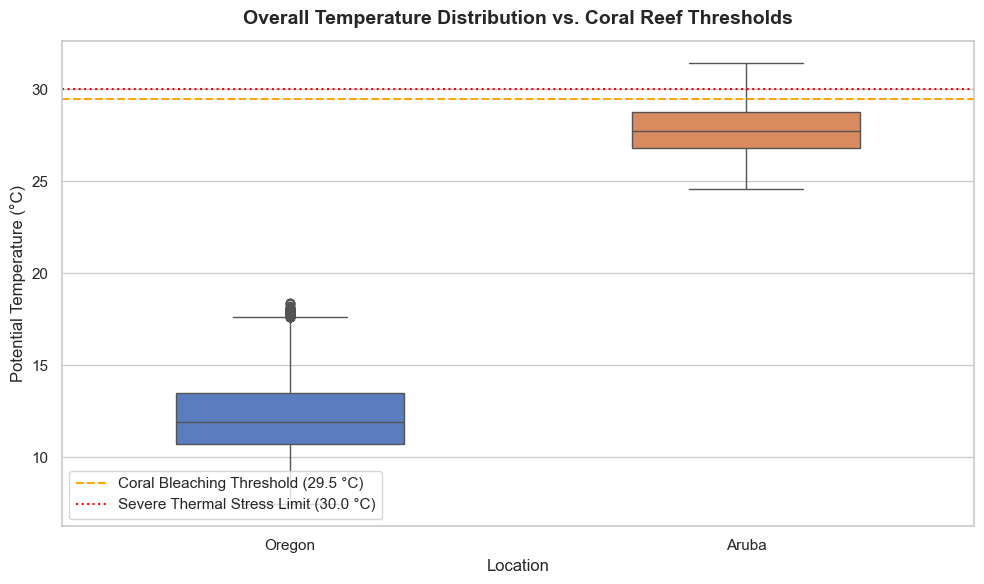

In [24]:
# Set visual style
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined_sal, x='Location', y='thetao', hue='Location', palette='muted', width=0.5, legend=False)
plt.axhline(y=29.5, color='orange', linestyle='--', linewidth=1.5, label='Coral Bleaching Threshold (29.5 °C)')
plt.axhline(y=30.0, color='red', linestyle=':', linewidth=1.5, label='Severe Thermal Stress Limit (30.0 °C)')
plt.title('Overall Temperature Distribution vs. Coral Reef Thresholds', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Potential Temperature (°C)', fontsize=12)
plt.xlabel('Location', fontsize=12)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

#### 9.2 Yearly Temperature Distribution vs. Coral Reef Thresholds

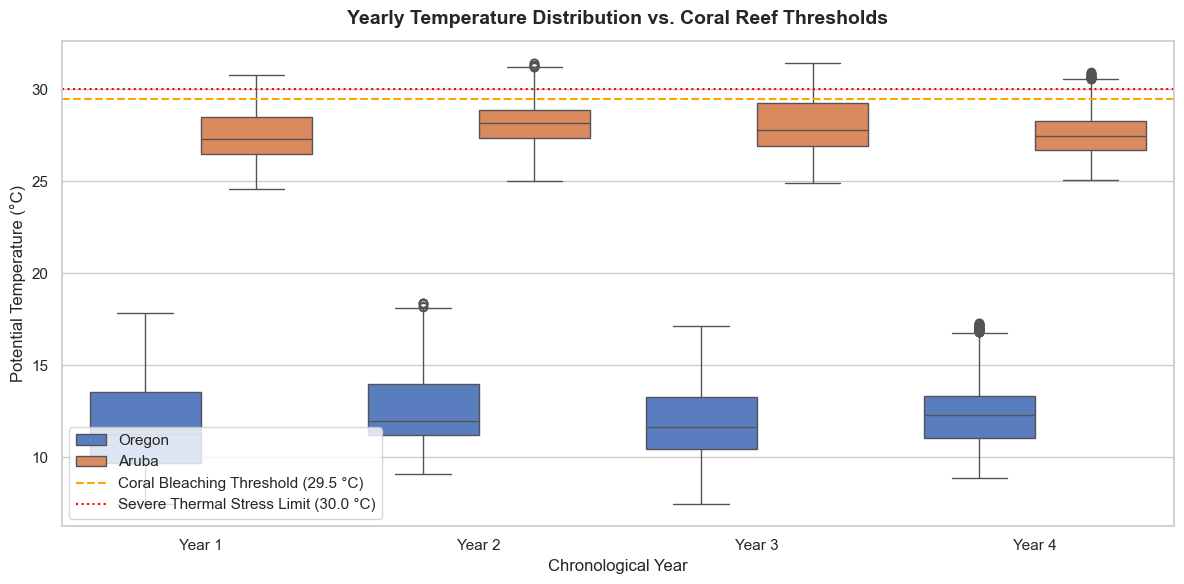

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined_sal, x='chrono_year', y='thetao', hue='Location', palette='muted', order=['Year 1', 'Year 2', 'Year 3', 'Year 4'])
plt.axhline(y=29.5, color='orange', linestyle='--', linewidth=1.5, label='Coral Bleaching Threshold (29.5 °C)')
plt.axhline(y=30.0, color='red', linestyle=':', linewidth=1.5, label='Severe Thermal Stress Limit (30.0 °C)')
plt.title('Yearly Temperature Distribution vs. Coral Reef Thresholds', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Potential Temperature (°C)', fontsize=12)
plt.xlabel('Chronological Year', fontsize=12)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

#### 9.3 Monthly Temperature Distribution vs. Coral Reef Thresholds (Seasonal Climatology)

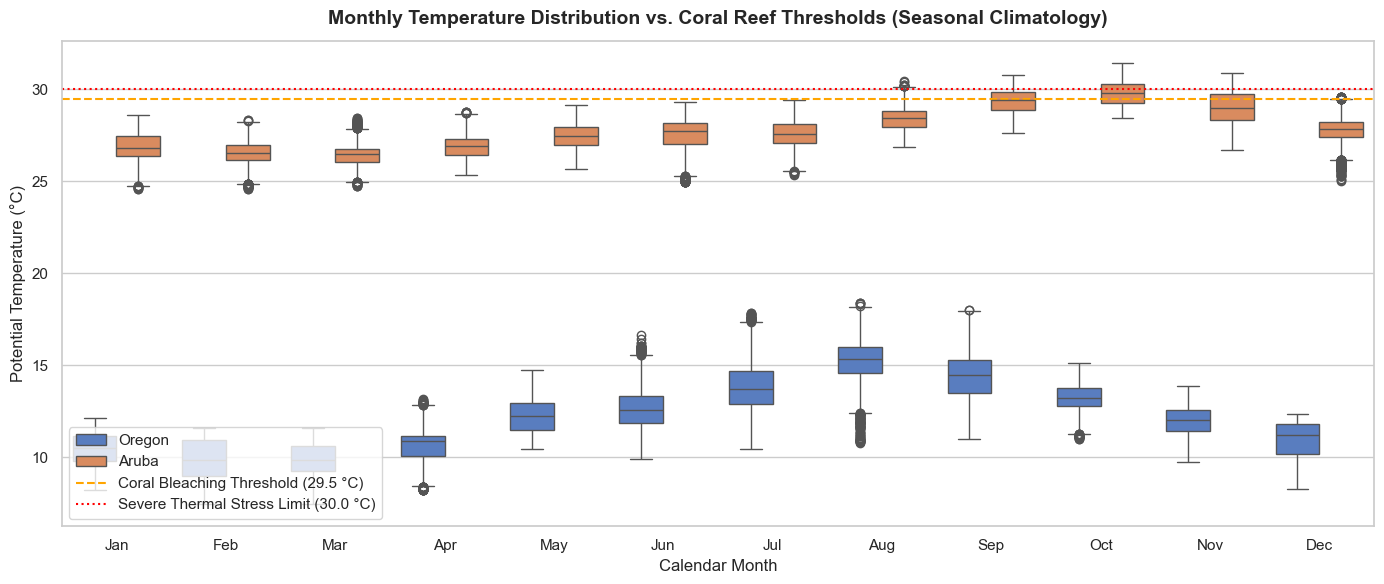

In [26]:
plt.figure(figsize=(14, 6))
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
if 'month_name_short' not in df_combined_sal.columns:
    df_combined_sal['month_name_short'] = df_combined_sal['time'].dt.strftime('%b')
sns.boxplot(data=df_combined_sal, x='month_name_short', y='thetao', hue='Location', palette='muted', order=months_order)
plt.axhline(y=29.5, color='orange', linestyle='--', linewidth=1.5, label='Coral Bleaching Threshold (29.5 °C)')
plt.axhline(y=30.0, color='red', linestyle=':', linewidth=1.5, label='Severe Thermal Stress Limit (30.0 °C)')
plt.title('Monthly Temperature Distribution vs. Coral Reef Thresholds (Seasonal Climatology)', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Potential Temperature (°C)', fontsize=12)
plt.xlabel('Calendar Month', fontsize=12)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()